Simulating bichromatic displacement (this may take a few seconds)...


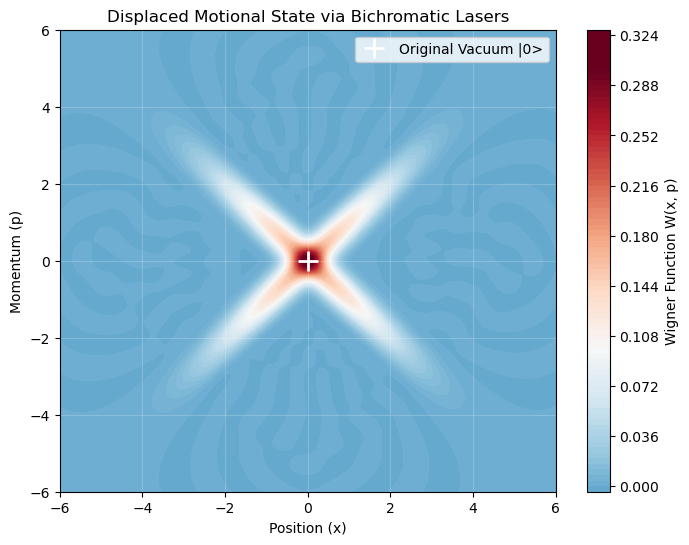

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\jewoo\.julia\packages\SciMLBase\pzpcE\src\integrator_interface.jl:626


In [14]:
using IonSim
using QuantumOptics
using PyPlot

# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
trap_freq = 1e6 # 1 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])

chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(;z=[1]))

mode_z = zmodes(chain)[1]
mode_z.N = 30 
mode_z.shape[1] = 31

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
k_vec = (x=1/√2, y=0, z=1/√2)
ϵ_vec = (x=1/√2, y=0, z=-1/√2)

# Goldilocks intensity (~550 kHz Rabi freq) to push hard without AC Stark scrambling
laser_intensity = 2e14 
transition_λ = 729e-9 
B_field = 1e-8

zeeman_offset = IonSim.zeemanshift(ion, "e", B_field) - IonSim.zeemanshift(ion, "g", B_field)

L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=(x=0,y=0,z=1), lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
mode = zmodes(trap)[1]

# THE SPIN FIX: Back to σ_y!
# We MUST prepare the ion in |+>_y to perfectly align with the bichromatic force.
ψ_ion = normalize(ion["g"] + 1im * ion["e"])

ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode

# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# lamb_dicke_order=1 builds the force, rwa_cutoff=Inf keeps the lasers alive.
h = hamiltonian(trap, timescale=1e-6, lamb_dicke_order=1, rwa_cutoff=Inf)

tspan = 0:1.0:100.0 
println("Simulating bichromatic displacement (this may take a few seconds)...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(30)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -6.0:0.1:6.0
p_vec = -6.0:0.1:6.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
contourf(x_vec, p_vec, W, 100, cmap="RdBu_r", vmin=-0.1, vmax=0.3)
colorbar(label="Wigner Function W(x, p)")

plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

xlabel("Position (x)")
ylabel("Momentum (p)")
title("Displaced Motional State via Bichromatic Lasers")
legend()
grid(color="white", alpha=0.2)

display(fig)

In [16]:
using LinearAlgebra: norm, tr

# println("\n" * "="^50)
# println("🕵️‍♂️ SQRLAB RAW DIAGNOSTICS REPORT")
# println("="^50)

# # ---------------------------------------------------------
# # DIAGNOSTIC 1: Exact Laser Detunings
# # ---------------------------------------------------------
# println("\n[DIAGNOSTIC 1] Laser Frequencies")
# println("Red Laser Detuning (Δ)  : ", L_red.Δ, " Hz")
# println("Blue Laser Detuning (Δ) : ", L_blue.Δ, " Hz")
# println("Trap Frequency (ω_m)    : ", trap_freq, " Hz")
# println("Difference (should match 2*ω_m): ", abs(L_blue.Δ - L_red.Δ), " Hz")

# # ---------------------------------------------------------
# # DIAGNOSTIC 2: Type Tracker for Rabi Frequency Math
# # ---------------------------------------------------------
# println("\n[DIAGNOSTIC 2] Coupling Math Breakdown")

# println("-> Step A: Evaluating Matrix Element...")
# c_matrix_elem = IonSim.matrixelement(ion, ("g", "e"), 1.0, L_red.k, L_red.ϵ, trap.Bhat)
# println("   Value  = ", c_matrix_elem)
# println("   Type   = ", typeof(c_matrix_elem))

# println("\n-> Step B: Evaluating Laser Intensity (L_red.I)...")
# println("   Value  = ", L_red.I)
# println("   Type   = ", typeof(L_red.I))
# println("   Notice: Is this a Float, or a time-dependent function wrapper?")

# println("\n-> Step C: Evaluating Physics Constants...")
# println("   IonSim.c  type = ", typeof(IonSim.c))
# println("   IonSim.ε₀ type = ", typeof(IonSim.ϵ₀))

# println("\n-> Step D: Step-by-Step Math execution...")
# try
#     println("   Attempting: 2 * L_red.I")
#     val1 = 2 * L_red.I
#     println("   [SUCCESS] Result = ", val1)
# catch e
#     println("   [FAILED]  Error: ", typeof(e))
# end

# try
#     println("\n   Attempting: Calling L_red.I at t=0.0 (e.g., L_red.I(0.0))")
#     val2 = 2 * L_red.I(0.0)
#     println("   [SUCCESS] Result = ", val2)
    
#     # If this succeeds, we can finish the math!
#     E_field_test = sqrt(val2 / (IonSim.c * IonSim.ϵ₀))
#     raw_rabi_test = abs(c_matrix_elem * E_field_test / IonSim.h)
#     println("   [SUCCESS] Computed Rabi Frequency = ", raw_rabi_test / 1e3, " kHz")
# catch e
#     println("   [FAILED]  Error: ", typeof(e))
# end

# ---------------------------------------------------------
# DIAGNOSTIC 3: Motional State (Phonon) Evolution
# ---------------------------------------------------------
b_fock_debug = FockBasis(mode_z.N)
a_op = QuantumOptics.destroy(b_fock_debug)
n_op = QuantumOptics.number(b_fock_debug)
x_op = (dagger(a_op) + a_op) / sqrt(2)
p_op = 1im * (dagger(a_op) - a_op) / sqrt(2)

phonon_tracking = Float64[]
x_tracking = Float64[]
p_tracking = Float64[]

for state in sol
    rho_m = ptrace(state, 1)
    rho_f = DenseOperator(b_fock_debug, rho_m.data)
    
    push!(phonon_tracking, real(expect(n_op, rho_f)))
    push!(x_tracking, real(expect(x_op, rho_f)))
    push!(p_tracking, real(expect(p_op, rho_f)))
end

println("\n[DIAGNOSTIC 3] Motional Growth")
println("Phonons at t = 0 μs   : ", phonon_tracking[1])
println("Phonons at t = 100 μs : ", phonon_tracking[end])
println("Max Phonons reached   : ", maximum(phonon_tracking))

println("\n[DIAGNOSTIC 6] Phase Space Translation")
println("Max Position <x> shifted: ", maximum(abs.(x_tracking)))
println("Max Momentum <p> shifted: ", maximum(abs.(p_tracking)))
# ---------------------------------------------------------
# DIAGNOSTIC 4: Internal Spin State Integrity
# ---------------------------------------------------------
P_e = ionprojector(trap, "e")
e_pops = real.(expect(P_e, sol))
max_deviation = maximum(abs.(e_pops .- 0.5))

println("\n[DIAGNOSTIC 4] Spin State Dynamics")
println("Initial |e> population : ", e_pops[1])
println("Final |e> population   : ", e_pops[end])
println("Max deviation from 0.5 : ", max_deviation)

# ---------------------------------------------------------
# DIAGNOSTIC 5: Motional State Purity
# ---------------------------------------------------------
purity_tracking = [real(tr(ptrace(state, 1)^2)) for state in sol]
println("\n[DIAGNOSTIC 5] Motional State Purity")
println("Initial Purity : ", purity_tracking[1])
println("Final Purity   : ", purity_tracking[end])
println("="^50 * "\n")

# # ---------------------------------------------------------
# # VISUAL DIAGNOSTICS PLOTS
# # ---------------------------------------------------------
# fig_debug, (ax1, ax2, ax3) = subplots(3, 1, figsize=(8, 10))

# ax1.plot(tspan, phonon_tracking, color="blue", linewidth=2)
# ax1.set_title("Diagnostic 3: Average Phonon Number ⟨n⟩ over time")
# ax1.set_ylabel("⟨n⟩")
# ax1.grid(true, linestyle="--")

# ax2.plot(tspan, e_pops, color="purple", linewidth=2)
# ax2.set_title("Diagnostic 4: Excited State Population P(e) (Should remain ~0.5)")
# ax2.set_ylabel("P(e)")
# ax2.set_ylim(0, 1)
# ax2.grid(true, linestyle="--")

# ax3.plot(tspan, purity_tracking, color="green", linewidth=2)
# ax3.set_title("Diagnostic 5: Motional State Purity (1.0 = Pure, <1.0 = Entangled)")
# ax3.set_xlabel("Time (μs)")
# ax3.set_ylabel("Tr(ρ²)")
# ax3.set_ylim(0, 1.1)
# ax3.grid(true, linestyle="--")

# tight_layout()
# display(fig_debug)


[DIAGNOSTIC 3] Motional Growth
Phonons at t = 0 μs   : 0.0
Phonons at t = 100 μs : 1.654535631117646
Max Phonons reached   : 1.654535631117646

[DIAGNOSTIC 6] Phase Space Translation
Max Position <x> shifted: 4.4961810338592714e-5
Max Momentum <p> shifted: 0.005161416875181652

[DIAGNOSTIC 4] Spin State Dynamics
Initial |e> population : 0.4999999999999999
Final |e> population   : 0.5228305393159421
Max deviation from 0.5 : 0.022830539315942144

[DIAGNOSTIC 5] Motional State Purity
Initial Purity : 0.9999999999999996
Final Purity   : 0.6470262571771946

